Archivo binario escrito: merid_local_bay_560x352.bin


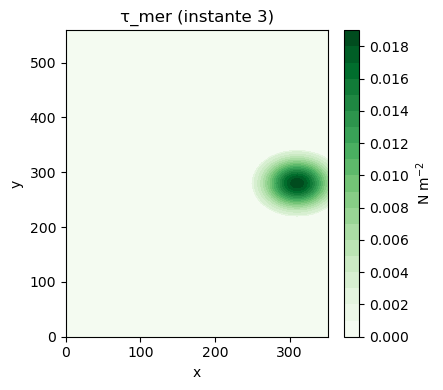

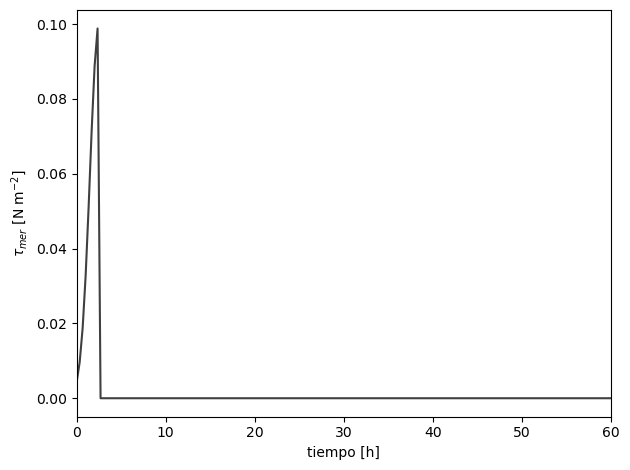

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def make_meridional_wind_patch(
        *,                    # obliga a usar argumentos por nombre → mayor claridad
        nt: int = 180,
        end_time: float = 60,          # h
        max_tau: float = 0.10,         # N m⁻²
        sigma_t: float = 1.0,          # h (efold temporal)
        center_t: float = 2.5,         # h (centro temporal)
        nx: int = 560,
        ny: int = 352,
        cx: int | None = None,         # centro x (celdas). None → nx//2
        cy: int | None = None,         # centro y (celdas). None → ny//2
        radius: int = 60,              # radio del parche (celdas)
        sigma_xy: float | None = None, # efold espacial. None → radius/2
        run_desc: str = 'windpatch',
        out_dir: str | Path = '.',
        write_bin: bool = True,
        dtype: str = '>f8',            # big-endian float64
        make_plots: bool = False
    ):
    """
    Genera un forzamiento meridional en forma de parche gaussiano espacio-tiempo.

    Devuelve:
        merid_tau  : ndarray (nx, ny, nt)
        fname_bin  : ruta del archivo .bin (None si write_bin=False)
    """
    # ---------- PARTE 1: pulso temporal -----------------------------------
    t = np.linspace(0, end_time, nt)                          # h
    gauss_t = max_tau * np.exp(-(t - center_t)**2 / (2*sigma_t**2))
    gauss_t[t > center_t] = 0                                 # media onda

    # ---------- PARTE 2: gaussiana espacial --------------------------------
    cx = cx if cx is not None else nx // 2
    cy = cy if cy is not None else ny // 2
    sigma_xy = sigma_xy if sigma_xy is not None else radius / 2

    x = np.arange(nx)[:, None]        # (nx,1)
    y = np.arange(ny)[None, :]        # (1,ny)
    r2 = (x - cx)**2 + (y - cy)**2
    gauss_xy = np.exp(-r2 / (2 * sigma_xy**2))
    gauss_xy[r2 > radius**2] = 0      # recorte opcional

    # ---------- PARTE 3: combina espacio y tiempo --------------------------
    windstress = gauss_xy[:, :, None] * gauss_t[None, None, :]  # (nx,ny,nt)
    alpha = np.radians(90)
    merid_tau = windstress * np.sin(alpha)                      # τ_mer

    # ---------- PARTE 4: escritura binaria ---------------------------------
    fname_bin = None
    if write_bin:
        out_dir = Path(out_dir)
        out_dir.mkdir(parents=True, exist_ok=True)
        fname_bin = out_dir / f'merid_{run_desc}_{nx}x{ny}.bin'

        with open(fname_bin, 'wb') as f:
            merid_tau.transpose(2, 1, 0).astype(dtype).tofile(f)
        print(f'Archivo binario escrito: {fname_bin}')

    # ---------- PARTE 5 (opcional): gráficos rápidos -----------------------
    if make_plots:
        # campo espacial (instante 3)
        plt.figure(figsize=(4.5,4))
        plt.contourf(merid_tau[:, :, 2], 20, cmap='Greens')
        plt.title('τ_mer (instante 3)')
        plt.colorbar(label='N m$^{-2}$')
        plt.xlabel('x'); plt.ylabel('y')
        plt.tight_layout(); plt.show()

        # pulso temporal
        plt.figure()
        plt.plot(t, gauss_t, '-', color='0.25')
        plt.xlabel('tiempo [h]'); plt.ylabel(r'$\tau_{mer}$ [N m$^{-2}$]')
        plt.xlim(0, end_time); plt.tight_layout(); plt.show()

    return merid_tau, fname_bin
# ---------------------------------------------------------------------------
# --------------------------  EJEMPLO RÁPIDO  -------------------------------
# ---------------------------------------------------------------------------
if __name__ == '__main__':
    # Parche de radio 40 celdas, centrado en (100, 150)
    _, fname = make_meridional_wind_patch(
        cx=280, cy=310,
        radius=60,
        run_desc='local_bay',
        make_plots=True
    )
    # fname → ruta del .bin listo para MITgcm


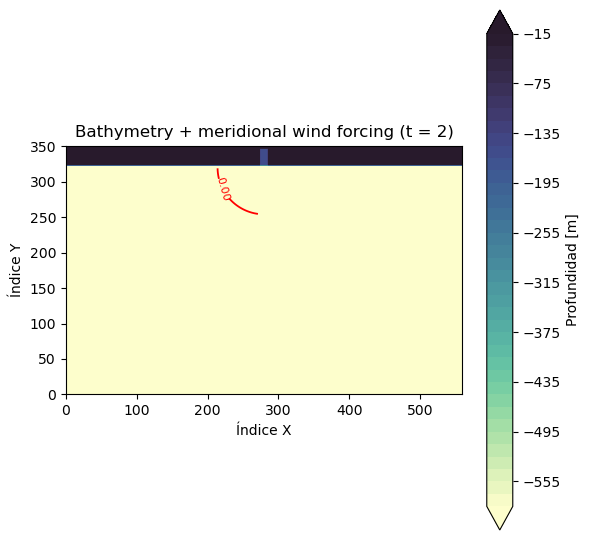

In [4]:
# ------------------------------------------------------------------
# 1)  IMPORTS Y PARÁMETROS BÁSICOS
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import cmocean as cmo                      # paletas oceánicas
from pathlib import Path

# 2)  LEE B A T I M E T R Í A  --------------------------------------
nx, ny = 560, 352
bathy_file = Path('/Volumes/Esteban_SSD/Maestría/MITgcm/verification/BayIW_Rectan_linear/input/bahia_01_expand_bat.bin')   # <-- ajusta ruta

bathy = np.fromfile(bathy_file, dtype='>f8')           # big-endian float64
bathy = bathy.reshape((nx, ny), order='F')             # (x,y) en orden Fortran

# 3)  GENERA (O LEE) TU PARCHE DE VIENTO ----------------------------
from wind_patch import make_meridional_wind_patch      # si la guardaste así

merid_tau, _ = make_meridional_wind_patch(
    cx=280, cy=320,       # mismo centro que antes
    radius=80,
    run_desc='visu',      # no importa, no vamos a escribir .bin
    write_bin=False
)

# 4)  FUNCIÓN DE GRÁFICO --------------------------------------------
def plot_forcing_on_bathy(bathy, merid_tau, tidx=2,   # tidx: índice temporal
                          cmap_bathy=cmo.cm.deep,
                          cmap_force='Reds', alpha_force=0.65):
    """
    Superpone contorno/sombreado del forzamiento (merid_tau) sobre la batimetría.
    bathy      : ndarray (nx,ny)
    merid_tau  : ndarray (nx,ny,nt)
    tidx       : instante que quieres visualizar
    """
    fig, ax = plt.subplots(figsize=(6,5.5))

    # --- Bathymetry background ------------------------------------
    bg = ax.contourf(bathy.T, 40, cmap=cmap_bathy, extend='both')
    cbar = fig.colorbar(bg, ax=ax, label='Profundidad [m]')

    # --- Wind-patch overlay ---------------------------------------
    tau_slice = merid_tau[:, :, tidx].T    # (y,x) para plot
    lvls = np.linspace(0.05*merid_tau.max(), merid_tau.max(), 6)

    # opción A: contornos
    cs = ax.contour(tau_slice, levels=lvls, colors='r', linewidths=1.3)
    ax.clabel(cs, fmt='%.2f', fontsize=8)

    # opción B (alternativa): sombreado semitransparente
    # ax.imshow(tau_slice, origin='lower', cmap=cmap_force,
    #           alpha=alpha_force, extent=[0,nx,0,ny])

    ax.set_title(f'Bathymetry + meridional wind forcing (t = {tidx})')
    ax.set_xlabel('Índice X'); ax.set_ylabel('Índice Y')
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

# 5)  LLAMA AL GRÁFICO ----------------------------------------------
plot_forcing_on_bathy(bathy, merid_tau, tidx=2)   # cambia tidx según necesites
